# 전류(Current_Proxy_I) 이상구간 비교 — 9/29 07:00~10:30 vs 평일 baseline

**계기**: 어제(2026-09-29) 07:00~10:30 사이 토출량(FT)·압력(PT)이 평소와 다르게 보임.
이 노트북은 그 시간대의 **전류 추정치**(`Cycle_Features_설명서.ipynb` 4-3 정의: `I = PT·FT/Hz`,
효율 K=1 생략, `전류_HzOut_임계값_및_K효율_분석.ipynb` 표기로는 `I_v1`)가 다른 날 같은
시간대 대비 얼마나 다른지를 **`g_s_SV`(레시피 목표유량) 값별로** 박스플롯(box-and-whisker)으로 비교한다.

- **대상 펌프**: P1(POL), I1(ISO) — 물리적으로 같은 축의 짝 (`env_kta_train`/`project_pump_anomaly` 메모리 참고)
- **이상 구간**: 2026-09-29(화) 07:00~10:30 KST
- **비교 baseline**: 2026-09-11~09-23 평일(월~금), 같은 07:00~10:30 시간대만
  - 최근 7일(9/23~9/29)엔 추석 연휴(9/24 목 ~ 9/27 일)가 껴 있어 제외
  - 주말(9/12,13,19,20)도 제외
  - `전류_HzOut_임계값_및_K효율_분석.ipynb`가 이미 이 구간을 캐시해 둬서(`cache/current_analysis_raw_{P1,I1}.pkl`) 재사용
- **안정구간 정의**: `Ticks_Since_Hz_Change >= STEADY_MIN(=5)` — 위 노트북에서 검증된 값 그대로 사용.
  (SV/Hz가 막 바뀐 직후 틱은 아직 증압 중이라 전류가 튀므로 제외)

같은 SV 값이라도 baseline 표본이 훨씬 많다(며칠치 vs 3시간 반). 그래서 그래프 옆에
표본수(n)·중앙값을 표로 같이 낸다 — 박스가 안 겹친다고 바로 "이상"이라 부르지 않고,
표본수까지 같이 보고 판단할 것.


In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor

PUMPS = ["P1", "I1"]
STEADY_MIN = 5                 # 전류_HzOut_임계값_및_K효율_분석.ipynb 에서 검증된 값

WINDOW_START = "07:00"
WINDOW_END = "10:30"

ABNORMAL_DAY = "2026-09-29"
# 사이클 경계/Hz 변경 이력이 끊기지 않도록 앞뒤로 살짝 여유를 두고 받는다.
ABNORMAL_PULL_START = "2026-09-29 06:30:00"
ABNORMAL_PULL_END = "2026-09-29 11:00:00"

# baseline: 전류_HzOut_임계값_및_K효율_분석.ipynb 가 이미 받아둔 2026-09-11~09-23 캐시를 재사용.
BASELINE_PULL_START = "2026-09-10T07:00:00Z"
BASELINE_PULL_END = "2026-09-23T18:00:00Z"

CACHE_DIR = os.path.join(ROOT_DIR, "parkkt", "cache")
os.makedirs(CACHE_DIR, exist_ok=True)
OUT_DIR = os.path.join(os.getcwd(), "analysis_out", "current_20260929_review")
os.makedirs(OUT_DIR, exist_ok=True)

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, CRITICAL = "#2a78d6", "#d03b3b"   # 정상=BLUE, 이상(9/29)=CRITICAL(경고색)


def style_ax(ax):
    ax.set_facecolor(SURFACE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=INK2)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


In [2]:
def _tags_for(pid):
    return [
        f"Pump_BuildUp_{pid}", f"g_s_SV_{pid}", f"Hz_Out_{pid}",
        f"Scale_Out___FT_{pid}", f"Scale_Out___PT_{pid}", f"Scale_Out___TT_{pid}",
        "AL_Line_Bit",
    ]


def load_raw(pid, cache_name, start, end):
    '''캐시가 있으면 그대로 쓰고, 없으면 InfluxDB에서 새로 받는다.
    펌프는 반드시 하나씩 받는다 (env_kta_train 메모리: 태그 구성이 틱 개수를 바꾼다).'''
    path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
    raw = ex.get_data(start_time=start, end_time=end, target_tags=_tags_for(pid))
    with open(path, "wb") as f:
        pickle.dump(raw, f)
    return raw


raw_baseline = {}
raw_abnormal = {}
for pid in PUMPS:
    raw_baseline[pid] = load_raw(pid, f"current_analysis_raw_{pid}.pkl",
                                  BASELINE_PULL_START, BASELINE_PULL_END)
    raw_abnormal[pid] = load_raw(pid, f"current_analysis_raw_{pid}_20260929.pkl",
                                  ABNORMAL_PULL_START, ABNORMAL_PULL_END)
    print(f"{pid}: baseline {len(raw_baseline[pid]):,}행 "
          f"({raw_baseline[pid].index.min()} ~ {raw_baseline[pid].index.max()}), "
          f"abnormal {len(raw_abnormal[pid]):,}행 "
          f"({raw_abnormal[pid].index.min()} ~ {raw_abnormal[pid].index.max()})")


P1: baseline 1,976,060행 (2026-09-10 16:00:00.406338 ~ 2026-09-24 02:59:59.596208), abnormal 29,353행 (2026-09-29 06:30:00.378785 ~ 2026-09-29 10:59:59.733973)
I1: baseline 1,980,516행 (2026-09-10 16:00:00.406338 ~ 2026-09-24 02:59:58.552095), abnormal 29,085행 (2026-09-29 06:30:00.378785 ~ 2026-09-29 10:59:59.733973)


## 1. 틱 단위 피처 만들기

`전류_HzOut_임계값_및_K효율_분석.ipynb`의 `build_tick_features`와 동일한 정의를 그대로 쓴다
(안정구간 판정·전류식·제외 규칙을 바꾸면 baseline과 비교가 안 맞게 되므로 그대로 재사용).

In [3]:
DAILY_EXCLUDE_START = "23:50"
DAILY_EXCLUDE_END = "07:00"


def _in_daily_exclude_window(ts):
    t = ts.time()
    start = pd.Timestamp(DAILY_EXCLUDE_START).time()
    end = pd.Timestamp(DAILY_EXCLUDE_END).time()
    return t >= start or t <= end


def build_tick_features(raw_df, pump_id):
    tag_SV = f"g_s_SV_{pump_id}"
    tag_PT = f"Scale_Out___PT_{pump_id}"
    tag_FT = f"Scale_Out___FT_{pump_id}"
    tag_BuildUp = f"Pump_BuildUp_{pump_id}"
    tag_Hz = f"Hz_Out_{pump_id}"

    df = raw_df.ffill().fillna(0).copy()
    df = df.reset_index().rename(columns={df.index.name or "Time": "Time"})
    if "Time" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Time"})

    buildup = df[tag_BuildUp].astype(int)
    df["Cycle_ID"] = (buildup.diff().fillna(0) != 0).cumsum()

    df_on = df[buildup == 1].sort_values("Time").reset_index(drop=True)
    df_on["Tick_Index"] = df_on.groupby("Cycle_ID").cumcount()

    hz_changed = df_on[tag_Hz].diff().fillna(0) != 0
    df_on["Hz_Change_Group"] = hz_changed.cumsum()
    df_on["Ticks_Since_Hz_Change"] = df_on.groupby("Hz_Change_Group").cumcount()

    hz = df_on[tag_Hz].replace(0, np.nan)
    df_on["I_v1"] = df_on[tag_PT] * df_on[tag_FT] / hz

    df_on["Day"] = df_on["Time"].dt.date
    df_on["Excluded_DailyWindow"] = df_on["Time"].apply(_in_daily_exclude_window)
    df_on["Excluded_Alarm"] = df_on["AL_Line_Bit"] > 0 if "AL_Line_Bit" in df_on.columns else False
    df_on["Excluded"] = df_on["Excluded_DailyWindow"] | df_on["Excluded_Alarm"]

    df_on["Hz_Out_raw"] = df_on[tag_Hz]
    df_on["PT_raw"] = df_on[tag_PT]
    df_on["FT_raw"] = df_on[tag_FT]
    df_on["SV_raw"] = df_on[tag_SV]

    return df_on


tick_baseline = {pid: build_tick_features(raw_baseline[pid], pid) for pid in PUMPS}
tick_abnormal = {pid: build_tick_features(raw_abnormal[pid], pid) for pid in PUMPS}
for pid in PUMPS:
    print(f"{pid}: baseline 가동틱 {len(tick_baseline[pid]):,}개 / "
          f"abnormal 가동틱 {len(tick_abnormal[pid]):,}개")


P1: baseline 가동틱 541,403개 / abnormal 가동틱 10,168개
I1: baseline 가동틱 537,906개 / abnormal 가동틱 10,101개


## 2. 07:00~10:30·평일·안정구간만 남기기

- baseline: 요일 월~금만, 시각 07:00~10:30만
- abnormal: 2026-09-29 07:00~10:30만
- 공통: `Excluded`(야간/알람) 아닌 것, `Ticks_Since_Hz_Change >= STEADY_MIN`인 것만

날짜별 표본수를 같이 찍어서 특정 하루가 데이터를 통째로 끌고 가는 건 아닌지 확인한다.

In [4]:
def in_window(df):
    t = df["Time"].dt.time
    return (t >= pd.Timestamp(WINDOW_START).time()) & (t <= pd.Timestamp(WINDOW_END).time())


def steady_ok(df):
    return (~df["Excluded"]) & (df["Ticks_Since_Hz_Change"] >= STEADY_MIN)


steady_baseline = {}
steady_abnormal = {}
for pid in PUMPS:
    b = tick_baseline[pid]
    b = b[in_window(b) & steady_ok(b)]
    b = b[b["Time"].dt.dayofweek < 5]   # 평일만
    steady_baseline[pid] = b.copy()

    a = tick_abnormal[pid]
    a = a[(a["Day"] == pd.Timestamp(ABNORMAL_DAY).date()) & in_window(a) & steady_ok(a)]
    steady_abnormal[pid] = a.copy()

    print(f"--- {pid} ---")
    print(f"baseline: {len(b):,}틱, 날짜 {sorted(b['Day'].unique())}")
    print(b.groupby("Day").size().rename("n_ticks").to_string())
    print(f"abnormal(9/29): {len(a):,}틱")
    print()


--- P1 ---
baseline: 68,821틱, 날짜 [datetime.date(2026, 9, 11), datetime.date(2026, 9, 14), datetime.date(2026, 9, 15), datetime.date(2026, 9, 16), datetime.date(2026, 9, 17), datetime.date(2026, 9, 18), datetime.date(2026, 9, 21), datetime.date(2026, 9, 22), datetime.date(2026, 9, 23)]
Day
2026-09-11    7970
2026-09-14    7397
2026-09-15    7301
2026-09-16    7018
2026-09-17    7828
2026-09-18    7359
2026-09-21    7977
2026-09-22    8920
2026-09-23    7051
abnormal(9/29): 6,541틱



--- I1 ---
baseline: 68,368틱, 날짜 [datetime.date(2026, 9, 11), datetime.date(2026, 9, 14), datetime.date(2026, 9, 15), datetime.date(2026, 9, 16), datetime.date(2026, 9, 17), datetime.date(2026, 9, 18), datetime.date(2026, 9, 21), datetime.date(2026, 9, 22), datetime.date(2026, 9, 23)]
Day
2026-09-11    7808
2026-09-14    7369
2026-09-15    7148
2026-09-16    7034
2026-09-17    7836
2026-09-18    7317
2026-09-21    8012
2026-09-22    8875
2026-09-23    6969
abnormal(9/29): 6,616틱



## 3. g_s_SV 구간별 박스플롯 — 전류(I_v1)

`g_s_SV`는 연속값이 아니라 레시피가 지정하는 **이산 목표값**이므로(예: P1은 2010/2150/2680/2980...),
Hz_Out처럼 등간격으로 나누지 않고 **실제 SV 값 하나하나를 그대로 구간으로 삼는다.**
baseline과 abnormal 양쪽에 최소 표본수(`MIN_N`) 이상 있는 SV 값만 비교 대상으로 남긴다
(한쪽에만 있는 SV는 애초에 비교가 안 되므로 제외하고, 아래 표에 몇 개 뺐는지 같이 남긴다).

P1: 표본부족(n<30)으로 제외된 SV 11개 — [(np.float64(2210.0), 230, 0), (np.float64(2260.0), 2424, 0), (np.float64(2300.0), 6367, 0), (np.float64(2410.0), 808, 0), (np.float64(2430.0), 1397, 0), (np.float64(2530.0), 140, 0), (np.float64(2560.0), 572, 0), (np.float64(2570.0), 208, 0), (np.float64(2740.0), 765, 0), (np.float64(2780.0), 313, 0), (np.float64(2980.0), 0, 49)]


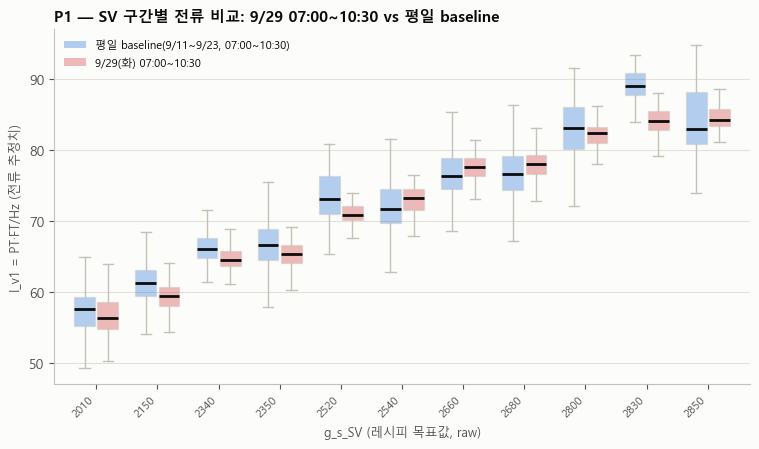

[P1] SV별 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
2010.0   13476   1117        57.59       56.39     -2.09
2150.0   16108   1265        61.38       59.45     -3.14
2340.0     169    220        66.11       64.62     -2.24
2350.0    3687    419        66.71       65.39     -1.97
2520.0     627    131        73.22       70.88     -3.18
2540.0     499    123        71.82       73.30      2.06
2660.0    1921    226        76.41       77.64      1.60
2680.0   17427   2483        76.69       78.12      1.87
2800.0     639    123        83.14       82.45     -0.83
2830.0     221    216        89.03       84.15     -5.49
2850.0     823    169        82.99       84.32      1.60

I1: 표본부족(n<30)으로 제외된 SV 9개 — [(np.float64(1110.0), 206, 0), (np.float64(1120.0), 534, 0), (np.float64(1140.0), 389, 0), (np.float64(1160.0), 297, 0), (np.float64(1230.0), 6312, 0), (np.float64(1260.0), 314, 0), (np.float64(1280.0), 798, 0), (np.float64(1300.0), 0, 46), (np.float64(1320.0), 1065, 0)

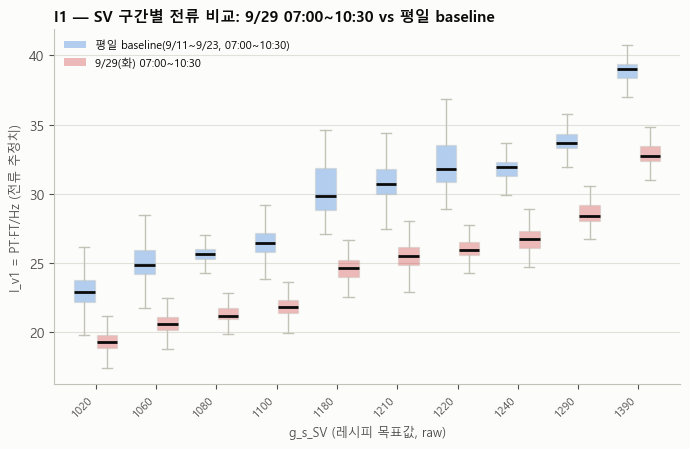

[I1] SV별 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
1020.0   15964   1260        22.88       19.26    -15.80
1060.0   12972   1026        24.86       20.61    -17.08
1080.0     166    220        25.66       21.20    -17.36
1100.0    4451    654        26.46       21.81    -17.56
1180.0     621    121        29.81       24.61    -17.43
1210.0   21601   2643        30.71       25.55    -16.83
1220.0    1078    164        31.80       25.94    -18.43
1240.0     226    214        31.91       26.71    -16.29
1290.0     873    140        33.65       28.42    -15.54
1390.0     501    128        39.01       32.76    -16.02



In [5]:
MIN_N = 30


def paired_sv_data(base_df, abn_df, value_col, min_n=MIN_N):
    sv_all = sorted(set(base_df["SV_raw"].unique()) | set(abn_df["SV_raw"].unique()))
    rows, kept, dropped = [], [], []
    for sv in sv_all:
        b = base_df.loc[base_df["SV_raw"] == sv, value_col].dropna().to_numpy()
        a = abn_df.loc[abn_df["SV_raw"] == sv, value_col].dropna().to_numpy()
        if len(b) < min_n or len(a) < min_n:
            dropped.append((sv, len(b), len(a)))
            continue
        kept.append(sv)
        rows.append({
            "SV": sv, "n_base": len(b), "n_abn": len(a),
            "median_base": np.median(b), "median_abn": np.median(a),
            "diff_pct": (np.median(a) - np.median(b)) / np.median(b) * 100,
        })
    return kept, rows, dropped


def draw_paired_box(ax, base_df, abn_df, value_col, sv_values):
    width = 0.34
    xt, xtl = [], []
    for i, sv in enumerate(sv_values):
        b = base_df.loc[base_df["SV_raw"] == sv, value_col].dropna().to_numpy()
        a = abn_df.loc[abn_df["SV_raw"] == sv, value_col].dropna().to_numpy()
        pb, pa = i - width / 2 - 0.02, i + width / 2 + 0.02
        bpb = ax.boxplot([b], positions=[pb], widths=width, patch_artist=True, showfliers=False)
        bpa = ax.boxplot([a], positions=[pa], widths=width, patch_artist=True, showfliers=False)
        for bp, color in [(bpb, BLUE), (bpa, CRITICAL)]:
            for box in bp["boxes"]:
                box.set(facecolor=color, alpha=0.35, edgecolor=AXIS, linewidth=1)
            for med in bp["medians"]:
                med.set(color=INK, linewidth=2)
            for part in ("whiskers", "caps"):
                for line in bp[part]:
                    line.set(color=AXIS, linewidth=1)
        xt.append(i)
        xtl.append(f"{sv:.0f}")
    ax.set_xticks(xt)
    ax.set_xticklabels(xtl, rotation=45, ha="right", fontsize=8)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=BLUE, alpha=0.35, label="평일 baseline(9/11~9/23, 07:00~10:30)"),
                        Patch(facecolor=CRITICAL, alpha=0.35, label="9/29(화) 07:00~10:30")],
               loc="upper left", fontsize=8, frameon=False)


summary_current = {}
for pid in PUMPS:
    kept, rows, dropped = paired_sv_data(steady_baseline[pid], steady_abnormal[pid], "I_v1")
    summary_current[pid] = pd.DataFrame(rows)
    if dropped:
        print(f"{pid}: 표본부족(n<{MIN_N})으로 제외된 SV {len(dropped)}개 — {dropped}")

    fig, ax = plt.subplots(figsize=(max(7, 0.7 * len(kept)), 4.6), facecolor=SURFACE)
    draw_paired_box(ax, steady_baseline[pid], steady_abnormal[pid], "I_v1", kept)
    style_ax(ax)
    ax.set_xlabel("g_s_SV (레시피 목표값, raw)", color=INK2, fontsize=9)
    ax.set_ylabel("I_v1 = PT·FT/Hz (전류 추정치)", color=INK2, fontsize=9)
    ax.set_title(f"{pid} — SV 구간별 전류 비교: 9/29 07:00~10:30 vs 평일 baseline",
                 color=INK, fontsize=11, loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"1_current_box_{pid}.png"), dpi=140)
    plt.show()

    print(f"[{pid}] SV별 중앙값 비교")
    print(summary_current[pid].round(2).to_string(index=False))
    print()


## 4. 참고 — 토출량(FT)·압력(PT) 자체도 같은 방식으로

전류가 다르다는 게 "펌프/모터 부하"가 다른 건지, 아니면 애초에 토출량·압력 자체가 그 시간대에
달랐던 건지(원래 이상하다고 느낀 지점) 구분하기 위해 같은 SV 구간·같은 그룹으로 FT/PT도 본다.

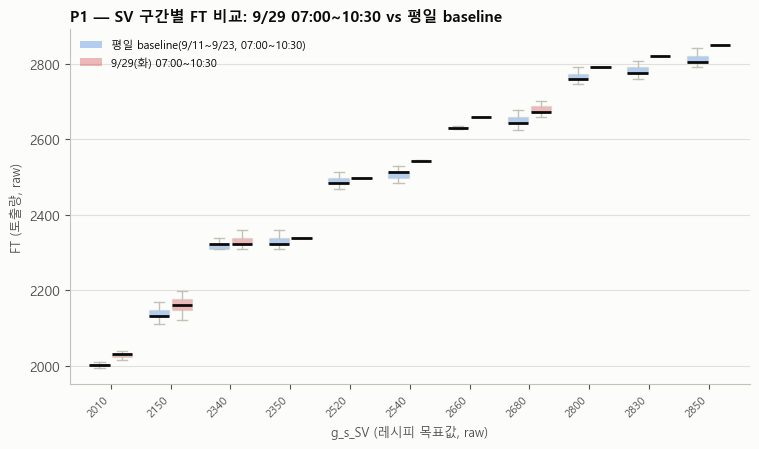

[P1] SV별 FT (토출량, raw) 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
2010.0   13476   1117       2001.0      2030.0      1.45
2150.0   16108   1265       2132.0      2162.0      1.41
2340.0     169    220       2322.0      2322.0      0.00
2350.0    3687    419       2322.0      2337.0      0.65
2520.0     627    131       2483.0      2498.0      0.60
2540.0     499    123       2512.0      2541.0      1.15
2660.0    1921    226       2629.0      2658.0      1.10
2680.0   17427   2483       2644.0      2673.0      1.10
2800.0     639    123       2760.0      2790.0      1.09
2830.0     221    216       2775.0      2819.0      1.59
2850.0     823    169       2804.0      2848.0      1.57



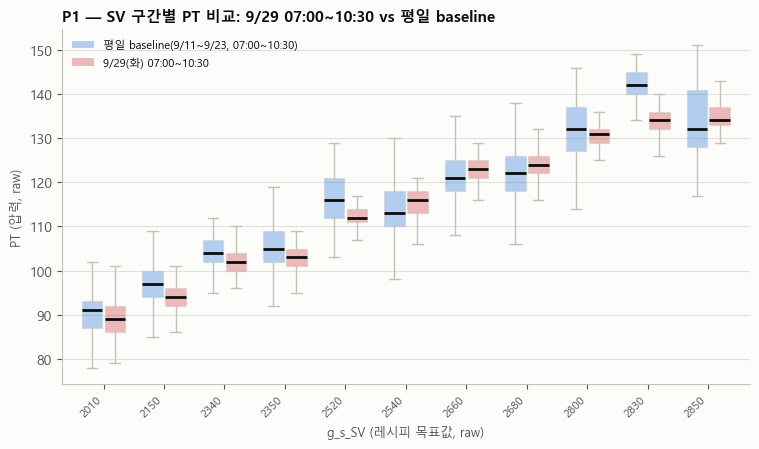

[P1] SV별 PT (압력, raw) 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
2010.0   13476   1117         91.0        89.0     -2.20
2150.0   16108   1265         97.0        94.0     -3.09
2340.0     169    220        104.0       102.0     -1.92
2350.0    3687    419        105.0       103.0     -1.90
2520.0     627    131        116.0       112.0     -3.45
2540.0     499    123        113.0       116.0      2.65
2660.0    1921    226        121.0       123.0      1.65
2680.0   17427   2483        122.0       124.0      1.64
2800.0     639    123        132.0       131.0     -0.76
2830.0     221    216        142.0       134.0     -5.63
2850.0     823    169        132.0       134.0      1.52



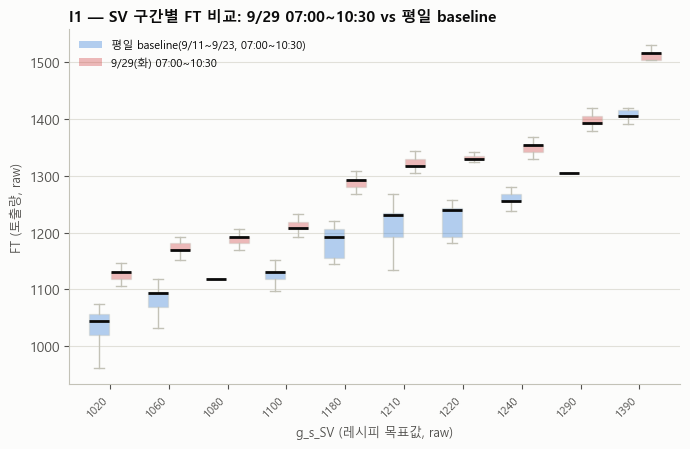

[I1] SV별 FT (토출량, raw) 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
1020.0   15964   1260       1044.0      1131.0      8.33
1060.0   12972   1026       1094.0      1169.0      6.86
1080.0     166    220       1119.0      1193.0      6.61
1100.0    4451    654       1131.0      1208.0      6.81
1180.0     621    121       1193.0      1293.0      8.38
1210.0   21601   2643       1231.0      1318.0      7.07
1220.0    1078    164       1240.0      1330.0      7.26
1240.0     226    214       1256.0      1355.0      7.88
1290.0     873    140       1305.0      1394.0      6.82
1390.0     501    128       1405.0      1517.0      7.97



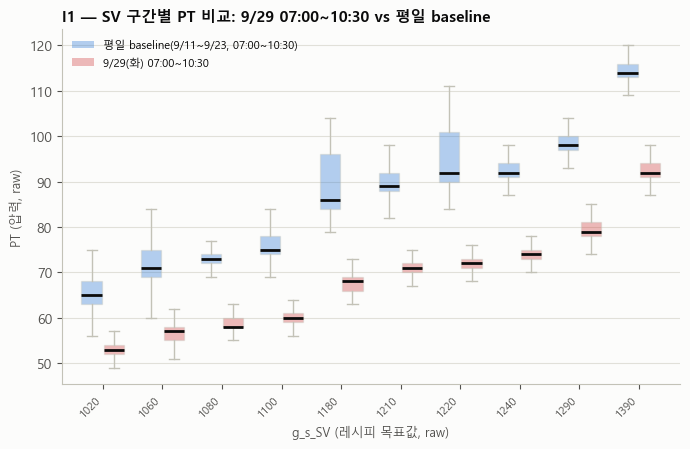

[I1] SV별 PT (압력, raw) 중앙값 비교
    SV  n_base  n_abn  median_base  median_abn  diff_pct
1020.0   15964   1260         65.0        53.0    -18.46
1060.0   12972   1026         71.0        57.0    -19.72
1080.0     166    220         73.0        58.0    -20.55
1100.0    4451    654         75.0        60.0    -20.00
1180.0     621    121         86.0        68.0    -20.93
1210.0   21601   2643         89.0        71.0    -20.22
1220.0    1078    164         92.0        72.0    -21.74
1240.0     226    214         92.0        74.0    -19.57
1290.0     873    140         98.0        79.0    -19.39
1390.0     501    128        114.0        92.0    -19.30



In [6]:
summary_ft, summary_pt = {}, {}
for pid in PUMPS:
    for value_col, store, ylabel, fname in [
        ("FT_raw", summary_ft, "FT (토출량, raw)", "2_ft_box"),
        ("PT_raw", summary_pt, "PT (압력, raw)", "3_pt_box"),
    ]:
        kept, rows, dropped = paired_sv_data(steady_baseline[pid], steady_abnormal[pid], value_col)
        store[pid] = pd.DataFrame(rows)

        fig, ax = plt.subplots(figsize=(max(7, 0.7 * len(kept)), 4.6), facecolor=SURFACE)
        draw_paired_box(ax, steady_baseline[pid], steady_abnormal[pid], value_col, kept)
        style_ax(ax)
        ax.set_xlabel("g_s_SV (레시피 목표값, raw)", color=INK2, fontsize=9)
        ax.set_ylabel(ylabel, color=INK2, fontsize=9)
        ax.set_title(f"{pid} — SV 구간별 {ylabel.split(' ')[0]} 비교: 9/29 07:00~10:30 vs 평일 baseline",
                     color=INK, fontsize=11, loc="left", fontweight="bold")
        fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, f"{fname}_{pid}.png"), dpi=140)
        plt.show()

        print(f"[{pid}] SV별 {ylabel} 중앙값 비교")
        print(store[pid].round(2).to_string(index=False))
        print()


## 5. 요약 표 — SV 구간 전체 평균 괴리율

각 펌프에서 공통 SV 구간들의 `diff_pct`(=（이상일 중앙값-baseline 중앙값）/baseline 중앙값)를
평균 내면, "이 펌프가 그 시간대에 전반적으로 몇 % 높았다/낮았다"를 한 줄로 요약할 수 있다.
SV 구간마다 표본수가 달라 단순 평균이 편향될 수 있으니 `n_abn` 가중평균도 같이 낸다.

In [7]:
for pid in PUMPS:
    df = summary_current[pid]
    if df.empty:
        print(f"{pid}: 비교 가능한 SV 구간 없음")
        continue
    simple_mean = df["diff_pct"].mean()
    weighted_mean = np.average(df["diff_pct"], weights=df["n_abn"])
    print(f"{pid}: I_v1(전류) 괴리율 — 단순평균 {simple_mean:+.1f}% / "
          f"n_abn 가중평균 {weighted_mean:+.1f}% (SV 구간 {len(df)}개 기준)")


P1: I_v1(전류) 괴리율 — 단순평균 -1.1% / n_abn 가중평균 -0.6% (SV 구간 11개 기준)
I1: I_v1(전류) 괴리율 — 단순평균 -16.8% / n_abn 가중평균 -16.8% (SV 구간 10개 기준)
